# Verified XAI for the Frozen AeroXAI PCA Detector

This notebook does **not** retrain, retune, or reselect the frozen detector.

It adds three verification mechanisms:

1. calibration-only contribution percentiles;
2. a causal 60-minute temporal evidence window;
3. model-space feature-group repair followed by the same PCA → EWMA → persistence alert pipeline.

Counterfactual repair tests **detector dependence** only. It is not a physical intervention and not a causal root-cause claim.


In [1]:
import json
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().resolve()
if not (ROOT / "ml").exists() and (ROOT.parent / "ml").exists():
    ROOT = ROOT.parent
if not (ROOT / "ml").exists():
    raise RuntimeError("Could not locate repository root.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.data.features import model_feature_columns
from ml.detection.alerts import causal_ewma, persistent_alerts
from ml.detection.pca_detector import fit_pca_detector, score_pca_detector
from ml.explainability.pca import (
    aggregate_contributions,
    causal_ewma_contributions,
    explain_pca_detector,
)
from ml.explainability.verification import (
    contribution_percentiles,
    fit_contribution_reference,
    temporal_evidence_window,
    verify_counterfactual_alert,
)

print("Repository root:", ROOT)


Repository root: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor


In [2]:
with (ROOT / "configs" / "metropt.yaml").open("r", encoding="utf-8") as handle:
    metropt = yaml.safe_load(handle)
with (ROOT / "configs" / "detection.yaml").open("r", encoding="utf-8") as handle:
    detection = yaml.safe_load(handle)
with (ROOT / "docs" / "xai_report.json").open("r", encoding="utf-8") as handle:
    frozen_xai = json.load(handle)

preprocessing = metropt["preprocessing"]
alert_config = detection["alerting"]
evaluation_config = detection["evaluation"]
pca_config = detection["pca"]
selection_config = detection["selection"]

if selection_config["primary"] != "pca_reconstruction":
    raise ValueError("Frozen primary detector is no longer PCA reconstruction.")

BIN_MINUTES = int(evaluation_config["bin_minutes"])
WINDOW_BINS = 12
REPORT_PATH = ROOT / "docs" / "xai_verification_report.json"

print("Frozen threshold:", frozen_xai["alerting"]["threshold"])
print("Verification window:", WINDOW_BINS * BIN_MINUTES, "minutes")


Frozen threshold: 52941.88448793303
Verification window: 60 minutes


In [3]:
def load_partition(path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame.index = pd.DatetimeIndex(frame.index, name="timestamp")
    return frame.sort_index()

train = load_partition(ROOT / preprocessing["train_file"])
calibration = load_partition(ROOT / preprocessing["calibration_file"])
test = load_partition(ROOT / preprocessing["test_file"])
feature_columns = model_feature_columns(train.columns)

pd.DataFrame(
    {
        "rows": [len(train), len(calibration), len(test)],
        "start": [train.index.min(), calibration.index.min(), test.index.min()],
        "end": [train.index.max(), calibration.index.max(), test.index.max()],
    },
    index=["train", "calibration", "test"],
)


,rows,start,end
train,5271,2020-02-01 00:05:00,2020-02-21 23:55:00
calibration,1796,2020-02-22 01:00:00,2020-02-28 23:55:00
test,43221,2020-03-01 04:05:00,2020-09-01 03:55:00


## Hard gate: reproduce the frozen detector

Stop if the PCA structure, threshold, alert state, or frozen incident scores do not reproduce.


In [4]:
detector = fit_pca_detector(
    train,
    feature_columns,
    variance_retained=float(pca_config["variance_retained"]),
    scaler_name=str(pca_config["scaler"]),
)

calibration_raw = score_pca_detector(calibration, detector)
calibration_smoothed = causal_ewma(
    calibration_raw,
    alpha=float(alert_config["ewma_alpha"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)
threshold = float(
    calibration_smoothed.quantile(
        float(alert_config["threshold_quantile"]),
        interpolation="higher",
    )
)

reproduction = {
    "threshold_matches": bool(np.isclose(
        threshold,
        float(frozen_xai["alerting"]["threshold"]),
        rtol=1e-12,
        atol=1e-9,
    )),
    "components_match": int(detector.model.n_components_) == int(
        frozen_xai["detector"]["components"]
    ),
    "explained_variance_matches": bool(np.isclose(
        float(detector.model.explained_variance_ratio_.sum()),
        float(frozen_xai["detector"]["explained_variance_ratio"]),
        rtol=1e-12,
        atol=1e-12,
    )),
}

print("Threshold:", threshold)
print("Components:", int(detector.model.n_components_))
print("Reproduction:", reproduction)

if not all(reproduction.values()):
    raise RuntimeError("Frozen detector reproduction failed.")


Threshold: 52941.88448793303
Components: 3
Reproduction: {'threshold_matches': True, 'components_match': True, 'explained_variance_matches': True}


In [5]:
test_raw = score_pca_detector(test, detector)
test_smoothed = causal_ewma(
    test_raw,
    alpha=float(alert_config["ewma_alpha"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)
_, test_alerts = persistent_alerts(
    test_smoothed,
    threshold=threshold,
    required_hits=int(alert_config["persistence_hits"]),
    window_bins=int(alert_config["persistence_window"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)

checks = []
for incident in frozen_xai["incidents"]:
    t = pd.Timestamp(incident["explanation_timestamp"])
    checks.append({
        "incident": int(incident["id"]),
        "alert": bool(test_alerts.loc[t]),
        "score_matches": bool(np.isclose(
            float(test_smoothed.loc[t]),
            float(incident["smoothed_score"]),
            rtol=1e-10,
            atol=1e-6,
        )),
    })

checks = pd.DataFrame(checks)
display(checks)

if not checks["alert"].all() or not checks["score_matches"].all():
    raise RuntimeError("Frozen incident alert reproduction failed.")


,incident,alert,score_matches
0,1,True,True
1,2,True,True
2,3,True,True
3,4,True,True


## Calibration-only normality context

The reference distribution is fitted from **smoothed grouped PCA contributions on calibration only**. Test incidents never influence the reference.


In [6]:
cal_exp = explain_pca_detector(calibration, detector)
cal_group_raw = aggregate_contributions(cal_exp.contributions)
cal_group_smoothed = causal_ewma_contributions(
    cal_group_raw,
    alpha=float(alert_config["ewma_alpha"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)
reference = fit_contribution_reference(cal_group_smoothed)

test_exp = explain_pca_detector(test, detector)
test_group_raw = aggregate_contributions(test_exp.contributions)
test_group_smoothed = causal_ewma_contributions(
    test_group_raw,
    alpha=float(alert_config["ewma_alpha"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)
test_percentiles = contribution_percentiles(
    test_group_smoothed,
    reference,
)

print("Calibration reference rows:", reference.sample_count)
print("Groups:", list(reference.groups))
print(
    "Percentile range:",
    float(test_percentiles.min().min()),
    float(test_percentiles.max().max()),
)


Calibration reference rows: 1796
Groups: ['tp2', 'tp3', 'h1', 'dv_pressure', 'reservoirs', 'oil_temperature', 'motor_current', 'comp', 'dv_electric', 'towers', 'mpg', 'lps', 'pressure_switch', 'oil_level', 'caudal_impulses', 'pressure_relationships']
Percentile range: 0.0 1.0


## Incident verification

For each frozen incident:

- rank **all** signal groups by smoothed contribution at the frozen alert;
- attach a calibration-context percentile;
- capture the previous 12 five-minute bins;
- test the top five groups individually;
- greedily repair groups in contribution order until the alert clears or all groups are repaired.

A complete 60-minute window is checked explicitly because MetroPT contains telemetry gaps.


In [7]:
def cf_dict(result):
    payload = asdict(result)
    payload["window_start"] = str(payload["window_start"])
    payload["window_end"] = str(payload["window_end"])
    payload["repaired_groups"] = list(payload["repaired_groups"])
    return payload


def window_is_complete(index, end_time):
    expected = pd.date_range(
        end=end_time,
        periods=WINDOW_BINS,
        freq=f"{BIN_MINUTES}min",
    )
    return bool(index.equals(expected))


verified = []

for incident in frozen_xai["incidents"]:
    incident_id = int(incident["id"])
    alert_time = pd.Timestamp(incident["explanation_timestamp"])

    contrib = test_group_smoothed.loc[alert_time].astype(float)
    percentiles = test_percentiles.loc[alert_time].astype(float)
    total = float(contrib.sum())
    ranking = contrib.sort_values(ascending=False).index.tolist()

    ranked_groups = []
    for group in ranking:
        value = float(contrib[group])
        ranked_groups.append({
            "group": group,
            "smoothed_contribution": value,
            "share": value / total if total > 0 else 0.0,
            "calibration_percentile": float(percentiles[group]),
        })

    temporal = temporal_evidence_window(
        test_percentiles,
        end_time=alert_time,
        window_bins=WINDOW_BINS,
        bin_minutes=BIN_MINUTES,
    )
    top_temporal_groups = ranking[:5]
    temporal_rows = [
        {
            "timestamp": str(timestamp),
            "percentiles": {
                group: float(row[group])
                for group in top_temporal_groups
            },
        }
        for timestamp, row in temporal[top_temporal_groups].iterrows()
    ]

    single_repairs = []
    for group in ranking[:5]:
        result = verify_counterfactual_alert(
            test,
            detector,
            test_raw,
            alert_timestamp=alert_time,
            groups=[group],
            window_bins=WINDOW_BINS,
            bin_minutes=BIN_MINUTES,
            ewma_alpha=float(alert_config["ewma_alpha"]),
            threshold=threshold,
            persistence_hits=int(alert_config["persistence_hits"]),
            persistence_window=int(alert_config["persistence_window"]),
            reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
        )
        single_repairs.append(cf_dict(result))

    greedy_steps = []
    cumulative = []
    minimum_groups_to_clear = None

    for group in ranking:
        cumulative.append(group)
        result = verify_counterfactual_alert(
            test,
            detector,
            test_raw,
            alert_timestamp=alert_time,
            groups=cumulative,
            window_bins=WINDOW_BINS,
            bin_minutes=BIN_MINUTES,
            ewma_alpha=float(alert_config["ewma_alpha"]),
            threshold=threshold,
            persistence_hits=int(alert_config["persistence_hits"]),
            persistence_window=int(alert_config["persistence_window"]),
            reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
        )
        step = cf_dict(result)
        step["step"] = len(cumulative)
        greedy_steps.append(step)

        if result.alert_cleared:
            minimum_groups_to_clear = len(cumulative)
            break

    verified.append({
        "id": incident_id,
        "incident_start": incident["incident_start"],
        "explanation_timestamp": str(alert_time),
        "timing": incident["timing"],
        "lead_hours": incident["lead_hours"],
        "delay_hours": incident["delay_hours"],
        "original_smoothed_score": float(test_smoothed.loc[alert_time]),
        "threshold": threshold,
        "ranked_groups": ranked_groups,
        "temporal_evidence": {
            "window_bins_requested": WINDOW_BINS,
            "window_rows_observed": len(temporal),
            "window_complete": window_is_complete(temporal.index, alert_time),
            "top_groups": top_temporal_groups,
            "rows": temporal_rows,
        },
        "single_group_repairs": single_repairs,
        "greedy_repair": {
            "ranking_basis": "smoothed contribution at frozen alert timestamp",
            "minimum_groups_to_clear": minimum_groups_to_clear,
            "steps": greedy_steps,
        },
        "causal_claim": False,
    })

print("Verified incidents:", len(verified))


Verified incidents: 4


In [8]:
summary_rows = []

for incident in verified:
    top = incident["ranked_groups"][0]
    top_group = top["group"]
    top_repair = next(
        item
        for item in incident["single_group_repairs"]
        if item["repaired_groups"] == [top_group]
    )

    summary_rows.append({
        "incident": incident["id"],
        "timing": incident["timing"],
        "top_group": top_group,
        "top_share": top["share"],
        "top_percentile": top["calibration_percentile"],
        "top_group_alone_clears_alert": bool(top_repair["alert_cleared"]),
        "minimum_groups_to_clear": incident["greedy_repair"]["minimum_groups_to_clear"],
        "temporal_window_complete": incident["temporal_evidence"]["window_complete"],
    })

summary = pd.DataFrame(summary_rows)
summary


,incident,timing,top_group,top_share,top_percentile,top_group_alone_clears_alert,minimum_groups_to_clear,temporal_window_complete
0,1,post_onset,tp2,0.939716,1.000000,True,1,False
1,2,pre_onset,dv_pressure,0.775629,0.995546,True,1,True
2,3,post_onset,tp2,0.860727,1.000000,True,1,True
3,4,pre_onset,dv_pressure,0.744966,0.995546,True,1,True


## Temporal evidence heatmaps

These plots show how unusual each dominant group's **contribution evidence** became relative to calibration behavior. They are not physical fault-onset estimates.


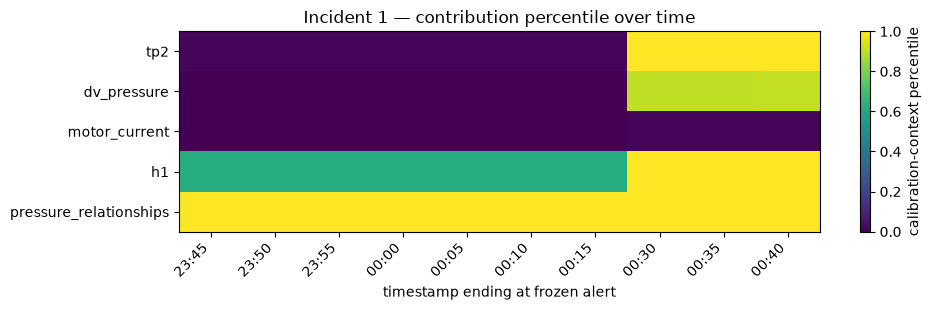

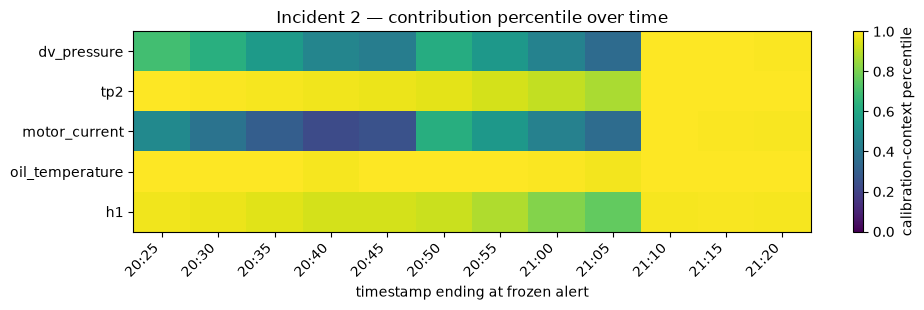

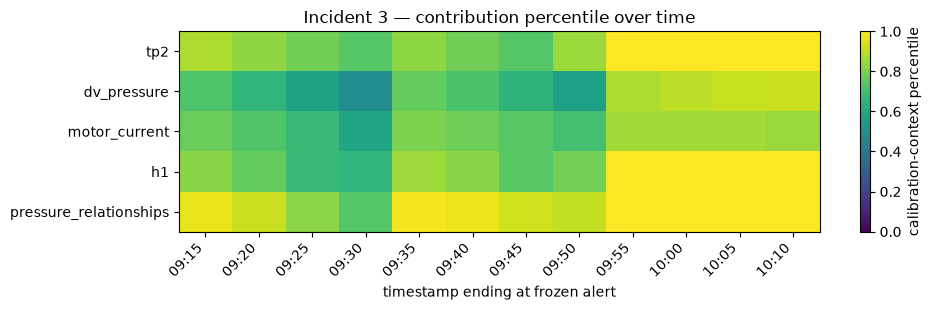

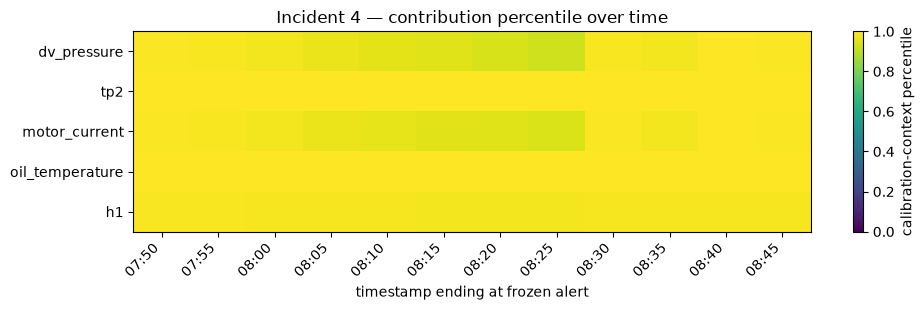

In [9]:
for incident in verified:
    temporal = incident["temporal_evidence"]
    rows = temporal["rows"]
    groups = temporal["top_groups"]

    matrix = np.asarray(
        [
            [row["percentiles"][group] for row in rows]
            for group in groups
        ],
        dtype=float,
    )
    labels = [
        pd.Timestamp(row["timestamp"]).strftime("%H:%M")
        for row in rows
    ]

    fig, ax = plt.subplots(figsize=(10, 3.2))
    image = ax.imshow(matrix, aspect="auto", vmin=0.0, vmax=1.0)
    ax.set_yticks(np.arange(len(groups)))
    ax.set_yticklabels(groups)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(
        f"Incident {incident['id']} — contribution percentile over time"
    )
    ax.set_xlabel("timestamp ending at frozen alert")
    fig.colorbar(image, ax=ax, label="calibration-context percentile")
    plt.tight_layout()
    plt.show()


## Write additive verification report

This creates `docs/xai_verification_report.json`. It does not overwrite the frozen detector/XAI reports.


In [10]:
all_percentiles_valid = bool(
    ((test_percentiles >= 0.0) & (test_percentiles <= 1.0)).all().all()
)
all_alerts = bool(checks["alert"].all())
all_scores = bool(checks["score_matches"].all())
all_past_only = all(
    pd.Timestamp(item["temporal_evidence"]["rows"][-1]["timestamp"])
    <= pd.Timestamp(item["explanation_timestamp"])
    for item in verified
)

report = {
    "evidence_class": "REAL",
    "evidence_subtype": "model_verification_on_real_telemetry",
    "dataset": "MetroPT-3",
    "detector": {
        "name": "pca_reconstruction",
        "scaler": str(pca_config["scaler"]),
        "components": int(detector.model.n_components_),
        "threshold": threshold,
        "detector_retrained": False,
        "detector_retuned": False,
    },
    "method": {
        "normality_context": (
            "Empirical percentiles of smoothed operator-level PCA "
            "contributions using calibration only."
        ),
        "temporal_evidence": (
            "Twelve causal five-minute bins ending at each frozen alert."
        ),
        "counterfactual_repair": (
            "Selected feature-group coordinates are replaced by the frozen "
            "PCA reconstruction in robust-scaled feature space, after which "
            "the repaired observation is reprojected and rescored."
        ),
        "alert_pipeline": (
            "Repaired raw scores pass through the same causal EWMA, frozen "
            "threshold, and persistence rule."
        ),
        "counterfactual_interpretation": (
            "Detector-dependence test only; not a physical intervention "
            "or causal root-cause estimate."
        ),
    },
    "acceptance": {
        **reproduction,
        "all_frozen_incident_alerts_reproduced": all_alerts,
        "all_frozen_incident_scores_reproduced": all_scores,
        "all_percentiles_in_unit_interval": all_percentiles_valid,
        "all_temporal_windows_past_only": all_past_only,
        "causal_claim": False,
    },
    "incidents": verified,
    "limitations": [
        "Contribution percentiles are not fault probabilities.",
        "Counterfactual repair occurs in PCA feature space, not physical equipment.",
        "Reprojection can alter residuals outside the repaired group.",
        "Greedy repair measures detector-decision concentration, not root cause.",
        "Temporal contribution emergence is not physical fault onset.",
    ],
}

acceptance_values = [
    value
    for key, value in report["acceptance"].items()
    if key != "causal_claim"
]
report["acceptance"]["all_passed"] = bool(all(acceptance_values))

REPORT_PATH.write_text(
    json.dumps(report, indent=2) + "\n",
    encoding="utf-8",
)

print("Report written:", REPORT_PATH)
print("Acceptance:", report["acceptance"])


Report written: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor/docs/xai_verification_report.json
Acceptance: {'threshold_matches': True, 'components_match': True, 'explained_variance_matches': True, 'all_frozen_incident_alerts_reproduced': True, 'all_frozen_incident_scores_reproduced': True, 'all_percentiles_in_unit_interval': True, 'all_temporal_windows_past_only': True, 'causal_claim': False, 'all_passed': True}


## Stop point

Before changing the frontend or backend, inspect the generated report scientifically.

We care about:

- whether dominant groups are also extreme relative to calibration;
- whether dominant-group repair clears the alert;
- how many groups the greedy repair needs;
- whether the temporal pattern is coherent;
- whether any 60-minute window is incomplete.

Do not retune the detector based on these results.
